# Largest Islands in the World

**Category:** Coding  

**Dataset:** largest-islands.csv - 100 rows, 6 columns, zero missing values 

**Objective:** Answer four structured questions using Pandas filtering,
grouping, sorting, and string operations. Plus one self-generated question.

**Goal:** Explore the world's 100 largest islands to answer four structured questions about climate, size, region, and governance.

---

In [1]:
# importing the necessary libraries and loading the dataset

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/largest-islands.csv')
df.head()

,region,island,area,countries,climate,rank
0,Africa,Madagascar,591896,Madagascar,tropics,4
1,Antarctic,Kerguelen,6200,"Antarctic Lands, France",temperate,91
2,Asia,Sumba,11153,Indonesia,tropics,65
3,Asia,Hainan,34300,China,tropics,37
4,Asia,Taiwan,36198,Taiwan,tropics,36


## 1. Data Exploration

This dataset is known to be clean but we verify rather than assume.

In [2]:
print("Shape: ")
print(df.shape)

print("\nColumn data type: ")
print(df.dtypes)

print("\nIsNull values: ")
print(df.isnull().sum())

print("\nNumeric Summary: ")
print(df.describe)


Shape: 
(100, 6)

Column data type: 
region         str
island         str
area         int64
countries      str
climate        str
rank         int64
dtype: object

IsNull values: 
region       0
island       0
area         0
countries    0
climate      0
rank         0
dtype: int64

Numeric Summary: 
<bound method NDFrame.describe of            region                           island    area  \
0          Africa                       Madagascar  591896   
1       Antarctic                        Kerguelen    6200   
2            Asia                            Sumba   11153   
3            Asia                           Hainan   34300   
4            Asia                           Taiwan   36198   
..            ...                              ...     ...   
95        Oceania                      Guadalcanal    5302   
96  South America                    East Falkland    6605   
97  South America                           Chiloe    8394   
98  South America  Isla Grande de Tierra d

In [ ]:
# calculate the unique values of region and climate
print("All region values: ")
print(df['region'].unique())

print("\nAll climate values: ")
print(df['climate'].unique())

All region values: 
<StringArray>
[       'Africa',     'Antarctic',          'Asia',       'Eurasia',
        'Europe', 'North America',       'Oceania', 'South America']
Length: 8, dtype: str

All climate values: 
<StringArray>
['tropics', 'temperate', 'polar']
Length: 3, dtype: str


## 2. Question 1 - Top 10 largest-islands in the Tropics

Top 10 largest-islands breaks down into exactly 3 operations,
1. Filter: filter the rows where climate == 'tropics'
2. Sort: by area, largest first (ascending=False)
3. Slice: take the top 10 by head(10)

In [4]:
# total number of tropical islands in top 100 islands
df['climate'].value_counts()

climate
tropics      41
temperate    32
polar        27
Name: count, dtype: int64

In [5]:
# filter only to the tropics climate
tropical_islands = df[df['climate'] == 'tropics']

# sort by area, descending order, top 10 islands
top_10_tropical = tropical_islands.sort_values('area', ascending=False).head(10)

# displaying the columns we need
top_10_tropical[['island', 'region', 'area']]

,island,region,area
86,New Guinea,Oceania,821400
23,Borneo,Asia,755000
0,Madagascar,Africa,591896
28,Sumatra,Asia,480793
22,Sulawesi,Asia,188522
21,Java,Asia,129438
80,Cuba,North America,109884
26,Luzon,Asia,104688
14,Mindanao,Asia,94630
73,Hispaniola,North America,76192


In [6]:
print(top_10_tropical['climate'].unique())

<StringArray>
['tropics']
Length: 1, dtype: str


## 3. Question 2 - Largest Island in each region.

We want the whole row with the max-area, not just the number.
groupby + idxmax() gives us the index of the max-area row per group, then df.loc[ ] retrieves the full row at that index.

In [7]:
# get the index of the max-area row within each region group
idx_of_largest = df.groupby('region')['area'].idxmax()

# get the full row with the idx_of_largest
largest_per_region = df.loc[idx_of_largest]

# display sorted by area so we can see the ranking
largest_per_region[['region', 'island', 'area']].sort_values('area', ascending=False)

,region,island,area
41,Europe,Greenland,2166086
86,Oceania,New Guinea,821400
23,Asia,Borneo,755000
0,Africa,Madagascar,591896
75,North America,Baffin Island,507451
35,Eurasia,Sakhalin,76400
98,South America,Isla Grande de Tierra del Fuego,47992
1,Antarctic,Kerguelen,6200


## 4. Question 3 - Area vs. Rank: How Sharply Do Island Size Drops?

Plotting area against rank to visualize the distribution.
Showing both linear and log scale side by side because:
- Linear Scale: shows how dominant Greenland is an outlier.
- Log Scale: reveals shape of decline across all 100 islands (which a linear scale visually compress into flat line near zero)

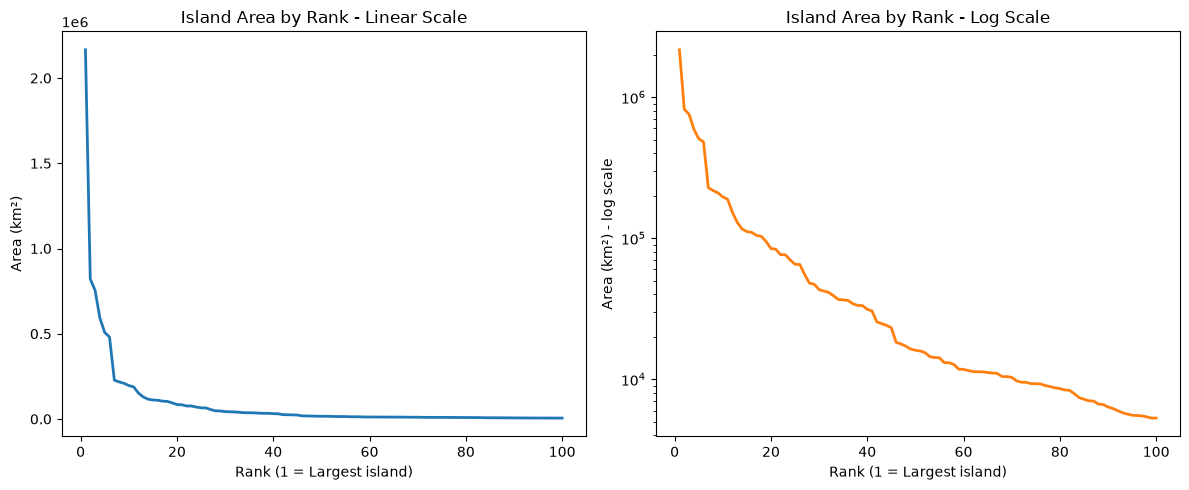

Chart saved to images/plots/area_by_rank_line_chart.png


In [ ]:
# sort by rank so the line goes left-to-right correctly
df_sorted = df.sort_values('rank')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left Chart: Linear Scale ---
axes[0].plot(df_sorted['rank'], df_sorted['area'], color='C0', linewidth=2)
axes[0].set_xlabel('Rank (1 = Largest island)')
axes[0].set_ylabel('Area (km²)')
axes[0].set_title("Island Area by Rank - Linear Scale")

# --- Right Chart: Log Scale ---
axes[1].plot(df_sorted['rank'], df_sorted['area'], color='C1', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_xlabel('Rank (1 = Largest island)')
axes[1].set_ylabel('Area (km²) - log scale')
axes[1].set_title("Island Area by Rank - Log Scale")

plt.tight_layout()

# saving the chart in images folder
plt.savefig('../images/plots/area_by_rank_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to images/plots/area_by_rank_line_chart.png")

## 5. Question 4 - Which Islands are Governed by Multiple Countries?

Multiple countries are stored as comma-separated text in one field.
str.contains(',') checks whether a comma exist in the string.
- A single country island has no comma, returns 'False' - filtered out
- A multi-country island has commas, returns 'True' - kept

In [9]:
# a comma in the 'countries' field signals multiple countries
multi_country = df[df['countries'].str.contains(',')]

print(f"Found {len(multi_country)} islands governed by multiple countries. \n")
multi_country[['island', 'countries', 'area']].sort_values('area', ascending=False)

Found 7 islands governed by multiple countries. 



,island,countries,area
86,New Guinea,"Papua New Guinea, Indonesia",821400
23,Borneo,"Indonesia, Malaysia, Brunei",755000
45,Ireland,"Ireland, United Kingdom",84421
73,Hispaniola,"Dominican Republic, Haiti",76192
98,Isla Grande de Tierra del Fuego,"Chile, Argentina",47992
50,Cyprus,"Cyprus, United Kingdom",9251
1,Kerguelen,"Antarctic Lands, France",6200


In [10]:
# rank climate by the number of islands
df.groupby('climate')['island'].count().sort_values(ascending=False)

climate
tropics      41
temperate    32
polar        27
Name: island, dtype: int64

In [11]:
# rank climate by total island area
df.groupby('climate')['area'].sum().sort_values(ascending=False)

climate
tropics      3862144
polar        3645900
temperate    1534741
Name: area, dtype: int64

## 6. My Own Question - Does Climate Zone Ranking by Island Count?

Match the ranking by Total Area?
These are actually two questions:
- "Which climate has the MOST islands?": count-based
- "Which climate has the MOST land?" : area-based

They can produce different rankings. For example: one climate could have fewer island but one enormous island that dominates the total area.

In [12]:
by_climate = df.groupby('climate').agg(
    island_count = ('island', 'count'),
    total_area_km2 = ('area', 'sum'),
    avg_area_km2 = ('area', 'mean')
)

print("Ranked by TOTAL AREA (km²):")
print(by_climate.sort_values('total_area_km2', ascending=False))
print()
print("Ranked by ISLAND COUNT: ")
print(by_climate.sort_values('island_count', ascending=False))

Ranked by TOTAL AREA (km²):
           island_count  total_area_km2   avg_area_km2
climate                                               
tropics              41         3862144   94198.634146
polar                27         3645900  135033.333333
temperate            32         1534741   47960.656250

Ranked by ISLAND COUNT: 
           island_count  total_area_km2   avg_area_km2
climate                                               
tropics              41         3862144   94198.634146
temperate            32         1534741   47960.656250
polar                27         3645900  135033.333333


## 7. Key Insights

- The tropics contain the most large islands overall, with **41** 
  of the top 100 islands being tropical
  
- Greenland (rank 1, North America region) dominates the area ranking — 
  the linear-scale chart shows it is roughly 14× larger than the 
  10th-ranked island, compressing everything else visually

- **7** islands in this dataset are governed by multiple countries,
  including Borneo (split between Indonesia, Malaysia, and Brunei), the 
  most internationally divided large island

- The climate ranking by total area **IS NOT** the same as the ranking
  by island count. Although the temperate climate contains more islands
  than the polar climate (32 vs. 27), the polar climate has a much
  greater total land area because it includes several exceptionally
  large islands, most notably Greenland.

- No data cleaning was required — verified via df.isnull().sum() (all zeros)
  and df.dtypes (consistent types throughout)